# Time-series example

This page is an end-to-end workflow for a **time-series**
[knowledge-primed neural network](../concepts/#kpnn) (KPNN): a prior
whose hidden nodes carry state across a sequence `x_t`. That memory is
an edge in the edgelist, not a module you import. You parse the graph,
write the time loop, train a small model, and interpret named nodes over
time.

Read [Feedforward example](../feedforward-example/) first. That
tutorial is a feedforward `parse_layered()` network on a
[directed acyclic graph](../concepts/#dag) (DAG).
[Cyclic graph example](../cyclic-graph-example/) is a feedback
prior on a **static** feature table. This page is what changes
when the data are a sequence.

What you get here:

- a tiny graph where a hidden node has a self-loop, so its
  value at `t` can depend on `t-1`
- `parse_adjacency()`, which allows that self-loop
- why `parse_layered()` cannot parse this graph
- one shared `MaskedLinear` over all nodes, applied once per
  time with a **new** `x_t` written into the input nodes
- training on simulated sequences whose class is an **early**
  pulse (the last frame is not enough)
- Captum scores on named nodes with a `step` axis
- a control that drops the self-loop and cannot solve the task

The recurrence is yours to write. The loop is ordinary PyTorch
and weights are shared across time; `kpnn2` does not unroll
time, pick the sequence length, or ship `MaskedRNN`. PyTorch
cannot supply it either: `nn.RNN` / `nn.GRU` / `nn.LSTM` own
dense `W_ih` / `W_hh` and take no edgelist. A gated recurrent
unit (GRU) or long short-term memory (LSTM) cell is the usual
gate equations with one `MaskedLinear` per map in your
`forward()`.

In [ ]:
import random

import numpy as np
import pandas as pd
import seaborn as sns
import torch
from graphviz import Digraph
from IPython.display import display
from matplotlib import pyplot as plt
from torch import nn

import kpnn2

In [ ]:
from matplotlib_inline.backend_inline import (
    set_matplotlib_formats,
)

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

set_matplotlib_formats(
    "svg",
    bbox_inches=None,
)
_FONT_SIZE = 14
_FIG_W = 7.0
_plot_rc = {
    "font.size": _FONT_SIZE,
    "axes.titlesize": _FONT_SIZE,
    "axes.labelsize": _FONT_SIZE,
    "xtick.labelsize": _FONT_SIZE,
    "ytick.labelsize": _FONT_SIZE,
    "legend.fontsize": _FONT_SIZE,
    "legend.title_fontsize": _FONT_SIZE,
    "lines.linewidth": 1.0,
    "font.family": "Liberation Sans",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "black",
    "axes.grid": False,
    "axes.facecolor": "none",
    "figure.facecolor": "none",
    "savefig.facecolor": "none",
    "savefig.edgecolor": "none",
    "svg.fonttype": "none",
}
plt.rcParams.update(_plot_rc)
sns.set_theme(
    style="ticks",
    rc=_plot_rc,
)


def _new_fig(height):
    return plt.figure(figsize=(_FIG_W, height))


def _style_ax(ax):
    ax.tick_params(labelsize=_FONT_SIZE)
    ax.title.set_fontsize(_FONT_SIZE)
    ax.xaxis.label.set_size(_FONT_SIZE)
    ax.yaxis.label.set_size(_FONT_SIZE)
    ax.set_facecolor("none")
    ax.grid(False)

## Define the graph

Memory is the only route from the data to the label. Two inputs
feed two hidden nodes. `node_a` has a self-loop, so it can
integrate `input_signal` across time. `node_b` is a distractor
with no memory. Both hidden nodes feed `output`.

- `input_signal` → `node_a` (and `node_a` → `node_a`)
- `input_noise` → `node_b`
- both hidden nodes → `output`

The edgelist format is the same two columns as [Feedforward
example](../feedforward-example/): `source` and `target`; only the
[parser](../concepts/#parser) changes. `parse_layered()` needs a DAG, so
it rejects the self-loop. `parse_adjacency()` ranks nothing, so
self-loops are allowed.


In [ ]:
edgelist = pd.DataFrame(
    {
        "source": [
            "input_signal",
            "input_noise",
            "node_a",
            "node_a",
            "node_b",
        ],
        "target": [
            "node_a",
            "node_b",
            "node_a",
            "output",
            "output",
        ],
    }
)

edgelist

,source,target
0,input_signal,node_a
1,input_noise,node_b
2,node_a,node_a
3,node_a,output
4,node_b,output


In [ ]:
try:
    kpnn2.parse_layered(edgelist)
except kpnn2.Kpnn2Error as error:
    print(error)

Edgelist contains 1 self-loop(s): node_a. Self-loops are not allowed.


In [ ]:
spec = kpnn2.parse_adjacency(edgelist)

(
    spec.nodes,
    spec.input_nodes,
    spec.hidden_nodes,
    spec.output_nodes,
)

(('input_noise', 'input_signal', 'node_a', 'node_b', 'output'),
 ('input_noise', 'input_signal'),
 ('node_a', 'node_b'),
 ('output',))

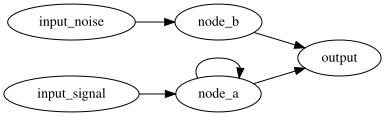

In [ ]:
dot = Digraph()
dot.attr(rankdir="LR")

for node_name in spec.nodes:
    dot.node(
        node_name,
        node_name,
    )

for row in edgelist.itertuples(index=False):
    dot.edge(
        str(row.source),
        str(row.target),
    )

dot

## Shared masked update over time

The model is one `MaskedLinear` over the whole [state
vector](../concepts/#state-vector), a single vector over all nodes,
applied once per frame. The state leaving step `t` enters step `t+1`,
and the self-loop on `node_a` lets a value survive that handover. The
structural work is the same as in
[Cyclic graph example](../cyclic-graph-example/); the data differ.
That page writes the **same** `x` in at every step so a signal can
travel around a feedback edge. Here each step gets a new `x_t`.

`parse_adjacency()` already did:

1. named node sets: `spec.input_nodes`, `spec.hidden_nodes`,
   `spec.output_nodes`
2. the edges as [packed indices](../concepts/#packed-indices), two
   parallel lists with one entry per edge; `spec.to_mask()` is the
   dense square for this small graph
3. where inputs and outputs sit in the state vector:
   `spec.input_index`, `spec.output_index`

The rest is ordinary PyTorch:

4. wrap `spec.to_mask()` in `MaskedLinear`
5. for each time `t`, write `x_t` into the input slots with
   `index_copy`, apply that shared layer, keep the state
6. read the output nodes after the last step and apply a linear
   head

`n_steps` is the sequence length you chose. `kpnn2` does not
unroll time.

Writing the inputs each step is required, not cosmetic. Input
nodes have in-degree 0, so their rows of `to_mask()` are zeros
and `fan_in` is 0. Under the degree-aware init those rows stay
at zero, so nothing would ever copy `x_t` into the state unless
the loop does it.

This graph is small, so `MaskedLinear` is appropriate. See
[PackedLinear](../packed_linear/) when `n_nodes` is large.

Each step's new state passes through its own `nn.Identity`, a tap
that Captum can hook. The taps hold no weights: every step uses the
same `self.core`, a normal child of the module.

The step has no activation. `output` is the only unit the head
reads, and `node_a` is the only unit with memory; a ReLU on either
passes no gradient once it sits below zero for every sample, so
training stalls. When you add an activation, put the module between
`self.core` and the tap, as in
[Layered vs. Adjacency](../layered_vs_adjacency/#how-you-compute).

In [ ]:
class TimeSeriesNet(nn.Module):
    def __init__(
        self,
        spec: kpnn2.AdjacencySpec,
        n_steps: int,
    ):
        super().__init__()
        self.spec = spec
        self.core = kpnn2.MaskedLinear(spec.to_mask())
        self.register_buffer(
            "input_index",
            torch.as_tensor(spec.input_index),
        )
        self.taps = nn.ModuleList([nn.Identity() for _ in range(n_steps)])
        self.head = nn.Linear(
            len(spec.output_nodes),
            1,
        )

    def forward(self, x):
        state = x.new_zeros(
            x.shape[0],
            self.core.in_features,
        )
        for t, tap in enumerate(self.taps):
            state = state.index_copy(
                -1,
                self.input_index,
                x[:, t, :],
            )
            state = tap(self.core(state))
        output = state[:, self.spec.output_index]
        return self.head(output)

Build the model for six frames, then start the self-loop weight at
`1`. The early pulse reaches the head only through that weight, once
per step. Its random start is below `1` in magnitude, so after three
or four steps little of the pulse, or of its gradient, is left. A
start of `1` carries the state forward unchanged until training
moves it. `spec.node_units()` gives the unit slice of `node_a`,
which indexes both the row and the column of the square weight.

In [ ]:
n_steps = 6
model = TimeSeriesNet(
    spec,
    n_steps,
)
self_loop = spec.node_units("node_a")
with torch.no_grad():
    model.core.weight[self_loop, self_loop] = 1.0

print(
    "taps:",
    len(model.taps),
)
print(
    "self-loop start:",
    model.core.weight.detach()[self_loop, self_loop].item(),
)

taps: 6
self-loop start: 1.0


## Simulate sequences, align, and train

The data are simulated so the right answer is known. Each
sample is `n_steps` frames of the two inputs. Class 1 has a
positive pulse on `input_signal` at times 0 and 1; class 0 does
not. `input_noise` is uninformative at every time. The last
frame looks similar in both classes, so a model without memory
cannot separate them.

`align_inputs()` returns a column index into the feature names.
Flatten `(sample, time)` into rows, apply that index, then reshape
to `(n_samples, n_steps, n_inputs)`. Train and test share that
index here because both frames use the same column order.
Pre-ordered dense tensors can skip that and go straight to the
model.


In [ ]:
def simulate_sequences(
    n_per_class,
    n_steps,
    feature_names,
    pulse_times,
    rng,
):
    n_features = len(feature_names)
    n_samples = 2 * n_per_class
    x = rng.normal(
        0.0,
        1.0,
        size=(n_samples, n_steps, n_features),
    )
    y = np.array([0] * n_per_class + [1] * n_per_class)
    signal_idx = feature_names.index("input_signal")
    class_1 = y == 1
    for time in pulse_times:
        x[class_1, time, signal_idx] += 1.8
    return x, y


def series_to_frame(x, feature_names):
    n_samples, n_times, _ = x.shape
    rows = []
    for i in range(n_samples):
        for time in range(n_times):
            row = {
                name: float(x[i, time, j])
                for j, name in enumerate(feature_names)
            }
            rows.append(row)
    return pd.DataFrame(rows)


feature_names = list(spec.input_nodes)
rng = np.random.default_rng(42)
pulse_times = (0, 1)

x_train_np, y_train = simulate_sequences(
    n_per_class=80,
    n_steps=n_steps,
    feature_names=feature_names,
    pulse_times=pulse_times,
    rng=rng,
)
x_test_np, y_test = simulate_sequences(
    n_per_class=40,
    n_steps=n_steps,
    feature_names=feature_names,
    pulse_times=pulse_times,
    rng=rng,
)

x_train_np.shape, feature_names

((160, 6, 2), ['input_noise', 'input_signal'])

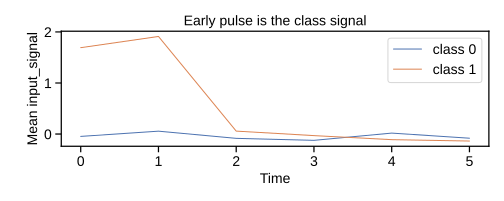

In [ ]:
signal_idx = feature_names.index("input_signal")
fig = _new_fig(2.8)
ax = fig.add_subplot(1, 1, 1)
for label, name in ((0, "class 0"), (1, "class 1")):
    series = x_train_np[y_train == label, :, signal_idx]
    ax.plot(
        range(n_steps),
        series.mean(axis=0),
        label=name,
    )
ax.set_xlabel("Time")
ax.set_ylabel("Mean input_signal")
ax.set_title("Early pulse is the class signal")
ax.legend()
_style_ax(ax)
plt.tight_layout()
plt.show()

Loss before first update: 0.7894
Loss after final update:  0.249
Test accuracy: 0.887


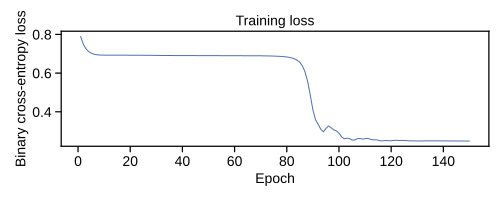

In [ ]:
train_frame = series_to_frame(x_train_np, feature_names)
test_frame = series_to_frame(x_test_np, feature_names)
# Same feature_names on both frames, so one col is valid.
col = kpnn2.align_inputs(train_frame.columns, spec)
x_train_flat = torch.as_tensor(
    train_frame.to_numpy()[:, col],
    dtype=torch.float32,
)
x_test_flat = torch.as_tensor(
    test_frame.to_numpy()[:, col],
    dtype=torch.float32,
)
n_inputs = len(spec.input_nodes)
x_train = x_train_flat.reshape(
    x_train_np.shape[0],
    n_steps,
    n_inputs,
)
x_test = x_test_flat.reshape(
    x_test_np.shape[0],
    n_steps,
    n_inputs,
)

y_train_tensor = torch.tensor(
    y_train.reshape(-1, 1),
    dtype=torch.float32,
)
y_test_tensor = torch.tensor(
    y_test.reshape(-1, 1),
    dtype=torch.float32,
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.05,
)
loss_fn = nn.BCEWithLogitsLoss()

n_epochs = 150
loss_history = []
model.train()
for _ in range(n_epochs):
    optimizer.zero_grad()
    logits = model(x_train)
    loss = loss_fn(logits, y_train_tensor)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

model.eval()
with torch.no_grad():
    pred = (model(x_test) > 0).float()
    test_acc = (pred == y_test_tensor).float().mean().item()

print(
    "Loss before first update:",
    round(loss_history[0], 4),
)
print(
    "Loss after final update: ",
    round(loss_history[-1], 4),
)
print("Test accuracy:", round(test_acc, 3))

fig = _new_fig(2.8)
ax = fig.add_subplot(1, 1, 1)
ax.plot(
    range(1, n_epochs + 1),
    loss_history,
    linewidth=1,
)
ax.set_xlabel("Epoch")
ax.set_ylabel("Binary cross-entropy loss")
ax.set_title("Training loss")
_style_ax(ax)
plt.tight_layout()
plt.show()

## Interpret nodes over time

A sequence adds a second question: not only which named node
matters, but **when**. Captum `LayerConductance` scores each
unrolled step, and `map_node_attributions()` labels the
sequence of `(batch, n_nodes)` tensors. Passing several tensors
stacks them on a `step` axis. `kpnn2` does not import Captum.
For the mapper itself, see
[Mapping attributions](../map-node-attributions/).

There is no `layer=` argument. An `AdjacencySpec` has no depths,
so the node axis is the whole state vector (`spec.nodes`).

Scores are on each step's **output** state. Input rows of
`to_mask()` are structurally zero, so neither input appears
there. `node_a` scores at every step before the last, because
its memory carries the early pulse forward. `node_b` has no
memory, so it scores only at step 4, the state that `output`
reads. `output` scores at the last step, the only unit the head
reads.

In [ ]:
from captum.attr import LayerConductance

model.eval()
per_step = []
for tap in model.taps:
    conductor = LayerConductance(
        model,
        tap,
    )
    attributions = conductor.attribute(
        x_test,
        target=0,
    )
    per_step.append(attributions)

da = kpnn2.map_node_attributions(
    attributions=tuple(per_step),
    spec=spec,
)
da.dims, tuple(da["node"].values)

(('step', 'observation', 'node'),
 (np.str_('input_noise'),
  np.str_('input_signal'),
  np.str_('node_a'),
  np.str_('node_b'),
  np.str_('output')))

node,input_noise,input_signal,node_a,node_b,output
step,,,,,
0,0.0,0.0,2.699,0.000,0.000
1,0.0,0.0,3.893,0.000,0.000
2,0.0,0.0,3.826,0.000,0.000
3,0.0,0.0,3.897,0.000,0.000
4,0.0,0.0,3.919,0.579,0.000
5,0.0,0.0,0.000,0.000,3.903


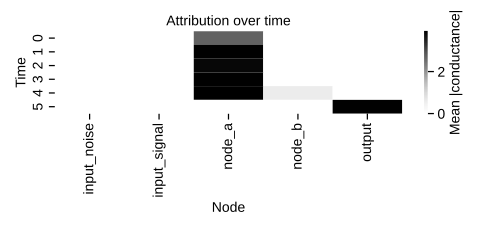

In [ ]:
mean_abs = np.abs(da).mean("observation").to_pandas()
mean_abs.index = mean_abs.index.map(str)
display(mean_abs.round(3))

fig = _new_fig(3.2)
ax = fig.add_subplot(1, 1, 1)
sns.heatmap(
    mean_abs,
    ax=ax,
    cmap="Greys",
    cbar_kws={"label": "Mean |conductance|"},
)
ax.set_xlabel("Node")
ax.set_ylabel("Time")
ax.set_title("Attribution over time")
_style_ax(ax)
plt.tight_layout()
plt.show()

## Why not `nn.RNN`?

PyTorch already ships recurrent modules, and none of them can
take a prior. `nn.RNN`, `nn.GRU`, and `nn.LSTM` are fused
convenience modules. An Elman step is a linear map plus a
nonlinearity; GRU and LSTM add more linear maps and the gate
mix. PyTorch bundles those maps with the time loop, packing,
and (on GPU) fused kernels.

The bundling is what rules them out: their maps are dense
parameters the module owns, not `nn.Linear` children you can
swap. There is no edgelist slot, so they cannot be the
recurrent map of a KPNN. Zeroing their weights after the fact is
not equivalent to `MaskedLinear`: the optimizer can fill the
zeros, init is not degree-aware, and names do not follow
`spec.nodes`.

So there is no `MaskedRNN` in `kpnn2`. The module above is the
assembly: `MaskedLinear` as the map, `for t` in your
`forward()`, and an activation module after the map for an
Elman step. That is short because a knowledge-primed Elman net
does not need packed sequences, cuDNN fusion, or bidirectional
stacks. Those are why PyTorch ships `nn.RNN`; a masked square
would not get them anyway.

A GRU or LSTM is the same idea with more maps. Each gate is a
`MaskedLinear` (the same `spec.to_mask()`, or a different
edgelist if you want a different prior per gate). The gate
equations stay ordinary PyTorch in your `nn.Module`. Whether
every gate shares one prior is a modeling choice, not something
`parse_adjacency()` decides.

## Control: no self-loop, no memory

The control isolates the one edge that carries state. Drop
`node_a → node_a` and change nothing else: same inputs, hidden
nodes, and output, and the same early-pulse data. With no
self-loop there is no weight to start at `1`. Each step
then reads only the current `x_t`, so the class signal is gone
by the last frame.

In [ ]:
edgelist_no_memory = pd.DataFrame(
    {
        "source": [
            "input_signal",
            "input_noise",
            "node_a",
            "node_b",
        ],
        "target": [
            "node_a",
            "node_b",
            "output",
            "output",
        ],
    }
)
spec_no_memory = kpnn2.parse_adjacency(edgelist_no_memory)
torch.manual_seed(42)
model_no_memory = TimeSeriesNet(
    spec_no_memory,
    n_steps,
)

optimizer = torch.optim.Adam(
    model_no_memory.parameters(),
    lr=0.05,
)
loss_history_no_memory = []
model_no_memory.train()
for _ in range(n_epochs):
    optimizer.zero_grad()
    logits = model_no_memory(x_train)
    loss = loss_fn(logits, y_train_tensor)
    loss.backward()
    optimizer.step()
    loss_history_no_memory.append(loss.item())

model_no_memory.eval()
with torch.no_grad():
    pred = (model_no_memory(x_test) > 0).float()
    acc_no_memory = (pred == y_test_tensor).float().mean().item()

print(
    "Loss before first update:",
    round(loss_history_no_memory[0], 4),
)
print(
    "Loss after final update: ",
    round(loss_history_no_memory[-1], 4),
)
print("Test accuracy:", round(acc_no_memory, 3))

Loss before first update: 0.6968
Loss after final update:  0.6893
Test accuracy: 0.438


Without the self-loop the loss stays near chance and test
accuracy does not separate the classes. The time loop was the
same; only the prior lost the edge that carries state. That is
the time-series analogue of a missing path in a static KPNN.

## Where to go next

- [Transformer example](../transformer-example/) uses the same
  packed indices as an attention allow-set.
- [Supported architectures](../supported/#sequence-models) shows
  how gated cells use one `MaskedLinear` per map.
- [Mapping attributions](../map-node-attributions/) covers the
  `step` axis and the other tensor layouts.
- [PackedLinear](../packed_linear/) replaces `MaskedLinear` when
  the `(n, n)` square would strain RAM.